# Analysis 2
We want to perform analysis for the 4 dataset reported in the paper "Closing the modality gap aligns group wise semantics".

## CIFAR 10

### Import and constants

In [1]:
import sys
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader    
import os
import sys
sys.path.append(os.path.abspath(".."))

from analysis.viz import visualize_3d, tsne_3d
from metrics.retrieval import compute_retrieval
from dataset.cifar10.cifar10_dataloader_with_labels import EmbeddingsDatasetWithLabels
from analysis.modality_gap import compute_gap
import procrustes
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split
from dataset.flickr30k.flickr_imagenet_utils import original_idx2class
from models.fusion_mlp_classifier import LinearProbing
# from models.fusion_mlp_classifier import FusionMLPClassifier
import torch.nn.functional as F
import torch 
import torch.nn as nn
import wandb
import copy
from torch.nn.utils import clip_grad_norm_
# Add parent directory to Python path so we can import `models.*`
seed = 123
g = torch.Generator().manual_seed(seed)

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, v_measure_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


/opt/anaconda3/envs/few_dim_modalitygap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define constants
dataset = "cifar10"  # or "flickr30k"
precomputed_dir = "/mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_train_ViT-B-32_laion2b_s34b_b79k"
precomputed_dir_test = "/mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_test_ViT-B-32_laion2b_s34b_b79k"

In [3]:
device = "cuda:3" if torch.cuda.is_available() else "cpu"

In [14]:

# dataset = EmbeddingsDatasetWithLabels(precomputed_dir)

In [4]:
def collect_embeddings(loader, max_samples=5000, device="cpu"):
    """
    Collects (text, vision) pairs from loader into numpy arrays.
    Each batch is (text_emb, vision_emb).
    """
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b, _ in tqdm(loader, desc=f"Collecting {max_samples} samples"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device), dim=-1).cpu().numpy()
            Xs.append(text_b); Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]
    return X, Y

def make_loaders(batch_size=256, seed=0, num_workers=0):
    ds_train = EmbeddingsDatasetWithLabels(precomputed_dir, split_name="train_shard")
    ds_test = EmbeddingsDatasetWithLabels(precomputed_dir_test, split_name="test_shard")
    n = len(ds_train)
    n_train = int(0.8 * n)
    n_test = n - n_train

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader


def _clustering_metrics_two_modalities(X, Y, labels, n_clusters=10, random_state=0):
    """
    KMeans su [X; Y] (2N, D) e metriche vs labels duplicate (2N,).
    """
    X_np = X.detach().cpu().numpy()
    Y_np = Y.detach().cpu().numpy()
    L_np = labels.detach().cpu().numpy()

    emb = np.vstack([X_np, Y_np])                       # (2N, D)
    true2 = np.concatenate([L_np, L_np], axis=0)        # (2N,)

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    pred = km.fit_predict(emb)

    return {
        "ARI": adjusted_rand_score(true2, pred),
        "NMI": normalized_mutual_info_score(true2, pred),
        "Homogeneity": homogeneity_score(true2, pred),
        "V-measure": v_measure_score(true2, pred),
        "cluster_labels": pred,
        "true_labels_2N": true2,
        "emb_2N": emb
    }


def _plot_pca_2d(emb_2N, labels_2N, title, max_points=6000):
    """
    PCA 2D veloce per visualizzare cluster/label (2N punti).
    Marker:
      - text: 'x'
      - vision: 'o'
    """
    n2 = emb_2N.shape[0]
    n = n2 // 2
    modality = np.concatenate([
        np.zeros(n, dtype=np.int32),          # text (first N)
        np.ones(n2 - n, dtype=np.int32)       # vision (second N)
    ])

    if n2 > max_points:
        idx = np.random.RandomState(0).choice(n2, size=max_points, replace=False)
        emb_2N = emb_2N[idx]
        labels_2N = labels_2N[idx]
        modality = modality[idx]

    pca = PCA(n_components=2, random_state=0)
    z = pca.fit_transform(emb_2N)

    plt.figure(figsize=(6, 5))

    # same colormap for labels, different marker for modality
    sc_vis = plt.scatter(
        z[modality == 1, 0], z[modality == 1, 1],
        c=labels_2N[modality == 1], s=20, marker='o', alpha=0.75, label='vision'
    )
    plt.scatter(
        z[modality == 0, 0], z[modality == 0, 1],
        c=labels_2N[modality == 0], s=20, marker='x', alpha=0.75,
        cmap=sc_vis.cmap, norm=sc_vis.norm, label='text'
    )

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(loc="best")
    plt.colorbar(sc_vis, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()



### Generic procrustes
we want to check what happens to retrieval and ap after applying generic Procrustes fitted on 10k samples from the train set and applying such matrix on the test set.

In [16]:
def fit_procrustes_on_10k(train_loader, n_fit=10_000, translate=True, scale=True):
    X_fit, Y_fit = collect_embeddings(train_loader, max_samples=n_fit, device=device)
    res = procrustes.generic(X_fit, Y_fit, translate=translate, scale=scale)
    T = res.t
    fit_err = float(res.error) if not hasattr(res.error, "item") else float(res.error.item())

    # store preprocessing stats consistent with translate/scale (standard)
    mu_X = X_fit.mean(axis=0, keepdims=True)
    mu_Y = Y_fit.mean(axis=0, keepdims=True)
    eps = 1e-12
    s_X = np.linalg.norm(X_fit - mu_X, ord="fro") + eps
    s_Y = np.linalg.norm(Y_fit - mu_Y, ord="fro") + eps

    return {"T": T, "mu_X": mu_X, "mu_Y": mu_Y, "s_X": s_X, "s_Y": s_Y, "fit_error": fit_err}

In [ ]:
def apply_mapping_torch(X: torch.Tensor, Y: torch.Tensor, mapping: dict, renorm: bool = True):
    """
    X, Y: torch tensors (B, D) on device
    mapping: dict with mu_X, s_X, mu_Y, s_Y, T (numpy or torch)
    Returns:
      X_al, Y_al: torch tensors (B, D)
    """
    eps = 1e-12

    # Ensure mapping params are torch tensors on the same device/dtype
    device = X.device
    dtype = X.dtype

    def to_torch(a):
        if torch.is_tensor(a):
            return a.to(device=device, dtype=dtype)
        return torch.as_tensor(a, device=device, dtype=dtype)

    mu_X = to_torch(mapping["mu_X"])
    s_X  = to_torch(mapping["s_X"])
    mu_Y = to_torch(mapping["mu_Y"])
    s_Y  = to_torch(mapping["s_Y"])
    T    = to_torch(mapping["T"])

    Xp = (X - mu_X) / (s_X + eps)
    Yp = (Y - mu_Y) / (s_Y + eps)

    X_al = Xp @ T
    Y_al = Yp

    if renorm:
        X_al = X_al / (X_al.norm(dim=1, keepdim=True) + eps)
        Y_al = Y_al / (Y_al.norm(dim=1, keepdim=True) + eps)

    return X_al, Y_al

In [18]:
train_loader, test_loader = make_loaders(precomputed_dir, batch_size=256, seed=0, num_workers=0)

mapping_10k = fit_procrustes_on_10k(train_loader, n_fit=10_000, translate=True, scale=True)

[Loaded] 50000 samples from /mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_train_ViT-B-32_laion2b_s34b_b79k | text_emb shape=(50000, 512)
[Loaded] 10000 samples from /mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_test_ViT-B-32_laion2b_s34b_b79k | text_emb shape=(10000, 512)


In [19]:
# Let's build a dict that contains for each label the correspoing embedded tensor
# in this case each label corresponds to a class in cifar10, so we will have 10 entries in the dict

#Let's get it from the training set, since it contains more samples per class and thus the average embedding will be more stable
label_to_embedding = {}
with torch.no_grad():
    for text_b, vis_b, labels in tqdm(train_loader, desc="Building label_to_embedding dict"):
        for text_emb, vis_emb, label in zip(text_b, vis_b, labels):
            label = label.item()
            if label not in label_to_embedding:
                label_to_embedding[label] = {"text": []}
                label_to_embedding[label] = text_emb

Building label_to_embedding dict: 100%|██████████| 196/196 [00:00<00:00, 327.44it/s]


In [ ]:
def eval_generic_procrustes(
    test_loader,
    dataset,
    label_to_embedding,
    mapping_model,
    direction="text_to_vision",
    do_clustering=True,
    n_clusters=10,
    max_cluster_samples=5000,
    plot_pca=True,
):
    gaps = ['RMG', 'L2M', 'L2I', 'cosineTP']
    r_orig = {1: [], 5: [], 10: []}
    r_al   = {1: [], 5: [], 10: []}

    gaps_orig_batches = {g: [] for g in gaps}
    gaps_al_batches   = {g: [] for g in gaps}

    # buffers per clustering
    X_buf, Y_buf, L_buf = [], [], []
    Xa_buf, Ya_buf = [], []

    def _to_scalar(v):
        if isinstance(v, dict):
            v = v.get("text_vision", next(iter(v.values())))
        if torch.is_tensor(v):
            v = v.item()
        return float(v)

    seen = 0

    with torch.no_grad():
        for text, vision, labels in tqdm(test_loader, desc="Eval test pre/post"):
            X = F.normalize(text.to(device), dim=-1)
            Y = F.normalize(vision.to(device), dim=-1)
            labels = labels.to(device)

            inputs = (X, Y, labels) if direction == "text_to_vision" else (Y, X, labels)

            # retrieval
            r_orig[1].append(_to_scalar(compute_retrieval(dataset, inputs, top_k=1,  labels_to_emb=label_to_embedding)))
            r_orig[5].append(_to_scalar(compute_retrieval(dataset, inputs, top_k=5,  labels_to_emb=label_to_embedding)))
            r_orig[10].append(_to_scalar(compute_retrieval(dataset, inputs, top_k=10, labels_to_emb=label_to_embedding)))

            # alignment
            X_al, Y_al = apply_mapping_torch(X, Y, mapping_model, renorm=True)
            inputs_al = (X_al, Y_al, labels) if direction == "text_to_vision" else (Y_al, X_al, labels)

            r_al[1].append(_to_scalar(compute_retrieval(dataset, inputs_al, top_k=1,  labels_to_emb=label_to_embedding)))
            r_al[5].append(_to_scalar(compute_retrieval(dataset, inputs_al, top_k=5,  labels_to_emb=label_to_embedding)))
            r_al[10].append(_to_scalar(compute_retrieval(dataset, inputs_al, top_k=10, labels_to_emb=label_to_embedding)))

            # gap per batch
            for gname in gaps:
                go = compute_gap(gname, X, Y, iterations=None)
                ga = compute_gap(gname, X_al, Y_al, iterations=None)
                gaps_orig_batches[gname].append(_to_scalar(go))
                gaps_al_batches[gname].append(_to_scalar(ga))

            # --- CLUSTERING BUFFERS ---
            if do_clustering and seen < max_cluster_samples:
                # salva su CPU per non intasare GPU RAM
                b = min(X.shape[0], max_cluster_samples - seen)
                X_buf.append(X[:b].detach().cpu())
                Y_buf.append(Y[:b].detach().cpu())
                Xa_buf.append(X_al[:b].detach().cpu())
                Ya_buf.append(Y_al[:b].detach().cpu())
                L_buf.append(labels[:b].detach().cpu())
                seen += b

    gaps_orig = {g: float(np.mean(vals)) for g, vals in gaps_orig_batches.items()}
    gaps_al   = {g: float(np.mean(vals)) for g, vals in gaps_al_batches.items()}

    print("\n=== TEST RESULTS (direction: {}) ===".format(direction))
    print(f"Procrustes fit_error on 10k: {mapping_model['fit_error']:.6f}")
    print(f"Retrieval@1  orig: {np.mean(r_orig[1]):.4f} | aligned: {np.mean(r_al[1]):.4f}")
    print(f"Retrieval@5  orig: {np.mean(r_orig[5]):.4f} | aligned: {np.mean(r_al[5]):.4f}")
    print(f"Retrieval@10 orig: {np.mean(r_orig[10]):.4f} | aligned: {np.mean(r_al[10]):.4f}")
    print("Gaps original:", gaps_orig)
    print("Gaps aligned :", gaps_al)

    # --- CLUSTERING E VISUALIZZAZIONE ---
    if do_clustering and len(X_buf) > 0:
        X_all  = torch.cat(X_buf, dim=0)
        Y_all  = torch.cat(Y_buf, dim=0)
        Xa_all = torch.cat(Xa_buf, dim=0)
        Ya_all = torch.cat(Ya_buf, dim=0)
        L_all  = torch.cat(L_buf, dim=0)

        print(f"\n[Clustering] using N={X_all.shape[0]} samples (then 2N points for KMeans).")

        m_orig = _clustering_metrics_two_modalities(X_all, Y_all, L_all, n_clusters=n_clusters, random_state=0)
        m_al   = _clustering_metrics_two_modalities(Xa_all, Ya_all, L_all, n_clusters=n_clusters, random_state=0)

        print(f"[Clustering KMeans k={n_clusters}]")
        print(f"  ORIG   ARI={m_orig['ARI']:.4f} | NMI={m_orig['NMI']:.4f} | Hom={m_orig['Homogeneity']:.4f} | V={m_orig['V-measure']:.4f}")
        print(f"  ALIGNED ARI={m_al['ARI']:.4f} | NMI={m_al['NMI']:.4f} | Hom={m_al['Homogeneity']:.4f} | V={m_al['V-measure']:.4f}")

        if plot_pca:
            _plot_pca_2d(m_orig["emb_2N"], m_orig["true_labels_2N"], title=f"PCA 2D (orig) dir={direction}")
            _plot_pca_2d(m_al["emb_2N"],   m_al["true_labels_2N"], title=f"PCA 2D (aligned) dir={direction}")

        # ritorno tutto comodo
        return {
            "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
            "retrieval_al":   {k: float(np.mean(v)) for k, v in r_al.items()},
            "gaps_orig": gaps_orig,
            "gaps_al": gaps_al,
            "clustering_orig": {k: m_orig[k] for k in ["ARI","NMI","Homogeneity","V-measure"]},
            "clustering_al":   {k: m_al[k] for k in ["ARI","NMI","Homogeneity","V-measure"]},
        }

    return {
        "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_al":   {k: float(np.mean(v)) for k, v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_al": gaps_al,
    }

Eval test pre/post: 100%|██████████| 40/40 [00:00<00:00, 92.34it/s]



=== TEST RESULTS (direction: vision_to_text) ===
Procrustes fit_error on 10k: 0.712636
Retrieval@1  orig: 0.7212 | aligned: 0.8776
Retrieval@5  orig: 0.9915 | aligned: 0.9824
Retrieval@10 orig: 1.0000 | aligned: 1.0000
Gaps original: {'RMG': 0.8870930965337542, 'L2M': 0.9383504062891006, 'L2I': 1.2117053806781768, 'cosineTP': 0.26562020778656004}
Gaps aligned : {'RMG': 0.6510791309961441, 'L2M': 0.07458789320662618, 'L2I': 0.9552555188536644, 'cosineTP': 0.5340358406305313}

[Clustering] using N=5000 samples (then 2N points for KMeans).
[Clustering KMeans k=10]
  ORIG   ARI=0.3888 | NMI=0.6394 | Hom=0.6320 | V=0.6394
  ALIGNED ARI=0.7799 | NMI=0.8522 | Hom=0.8486 | V=0.8522


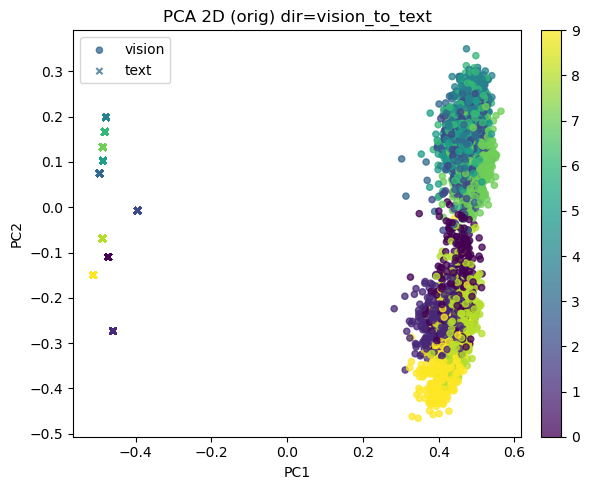

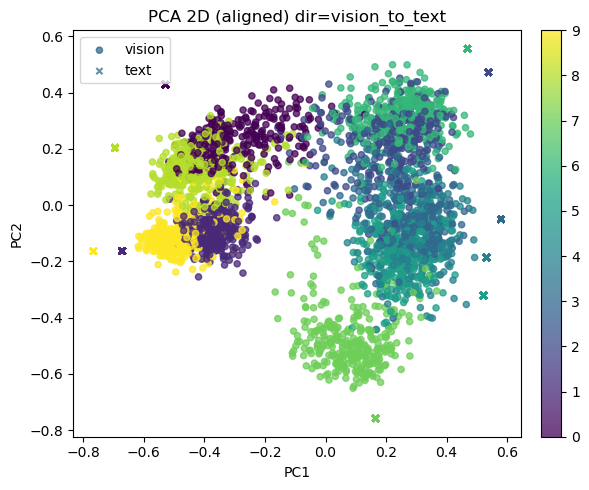

{'retrieval_orig': {1: 0.72119140625, 5: 0.99150390625, 10: 1.0},
 'retrieval_al': {1: 0.87763671875, 5: 0.982421875, 10: 1.0},
 'gaps_orig': {'RMG': 0.8870930965337542,
  'L2M': 0.9383504062891006,
  'L2I': 1.2117053806781768,
  'cosineTP': 0.26562020778656004},
 'gaps_al': {'RMG': 0.6510791309961441,
  'L2M': 0.07458789320662618,
  'L2I': 0.9552555188536644,
  'cosineTP': 0.5340358406305313},
 'clustering_orig': {'ARI': 0.3887693671620999,
  'NMI': np.float64(0.639405123169085),
  'Homogeneity': np.float64(0.6319788285917483),
  'V-measure': np.float64(0.639405123169085)},
 'clustering_al': {'ARI': 0.7798867420047184,
  'NMI': np.float64(0.8521640509809901),
  'Homogeneity': np.float64(0.8486324899242559),
  'V-measure': np.float64(0.8521640509809901)}}

In [23]:
out = eval_generic_procrustes(
    test_loader, dataset, label_to_embedding, mapping_10k,
    direction="vision_to_text",
    do_clustering=True,
    n_clusters=10,
    max_cluster_samples=5000,
    plot_pca=True
)
out

### Orthogonal Procrustes

In [5]:
import numpy as np
from procrustes.orthogonal import orthogonal

In [17]:
# Define constants
dataset = "cifar10"  # or "flickr30k"
precomputed_dir = "/mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_train_ViT-B-32_laion2b_s34b_b79k"
precomputed_dir_test = "/mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_test_ViT-B-32_laion2b_s34b_b79k"
device = "cuda:3" if torch.cuda.is_available() else "cpu"

train_loader, test_loader = make_loaders( batch_size=256, seed=0, num_workers=0)

[Loaded] 50000 samples from /mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_train_ViT-B-32_laion2b_s34b_b79k | text_emb shape=(50000, 512)
[Loaded] 10000 samples from /mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_test_ViT-B-32_laion2b_s34b_b79k | text_emb shape=(10000, 512)


In [19]:
# Let's build a dict that contains for each label the correspoing embedded tensor
# in this case each label corresponds to a class in cifar10, so we will have 10 entries in the dict

#Let's get it from the training set, since it contains more samples per class and thus the average embedding will be more stable
label_to_embedding = {}
with torch.no_grad():
    for text_b, vis_b, labels in tqdm(train_loader, desc="Building label_to_embedding dict"):
        for text_emb, vis_emb, label in zip(text_b, vis_b, labels):
            label = label.item()
            if label not in label_to_embedding:
                label_to_embedding[label] = {"text": []}
                label_to_embedding[label] = text_emb

Building label_to_embedding dict: 100%|██████████| 196/196 [00:00<00:00, 427.49it/s]


Eval orthogonal pre/post: 100%|██████████| 40/40 [00:00<00:00, 84.66it/s]



=== TEST RESULTS ORTHOGONAL (direction: vision_to_text) ===
Orthogonal fit_error on 10k: 4007.281982
Retrieval@1  orig: 0.7212 | aligned: 0.8781
Retrieval@5  orig: 0.9915 | aligned: 0.9827
Retrieval@10 orig: 1.0000 | aligned: 1.0000
Gaps original: {'RMG': 0.8870930965337542, 'L2M': 0.9383504062891006, 'L2I': 1.2117053806781768, 'cosineTP': 0.26562020778656004}
Gaps aligned : {'RMG': 0.6629355509226955, 'L2M': 0.0832027131691575, 'L2I': 0.980792686343193, 'cosineTP': 0.5089237883687019}

[Clustering] using N=5000 samples (then 2N points for KMeans).
[Clustering KMeans k=10]
  ORIG   ARI=0.3888 | NMI=0.6394 | Hom=0.6320 | V=0.6394
  ALIGNED ARI=0.7667 | NMI=0.8486 | Hom=0.8430 | V=0.8486


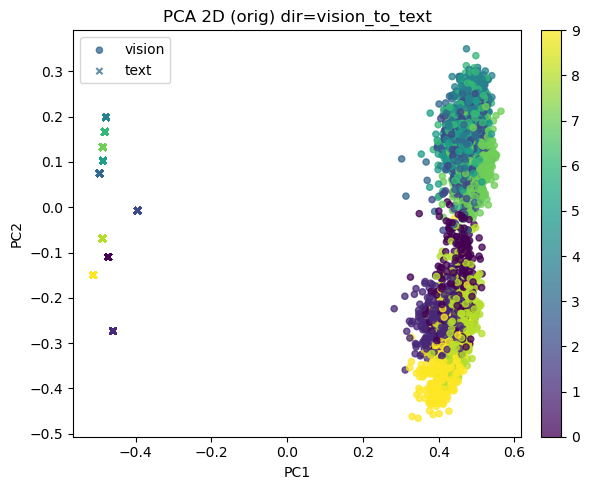

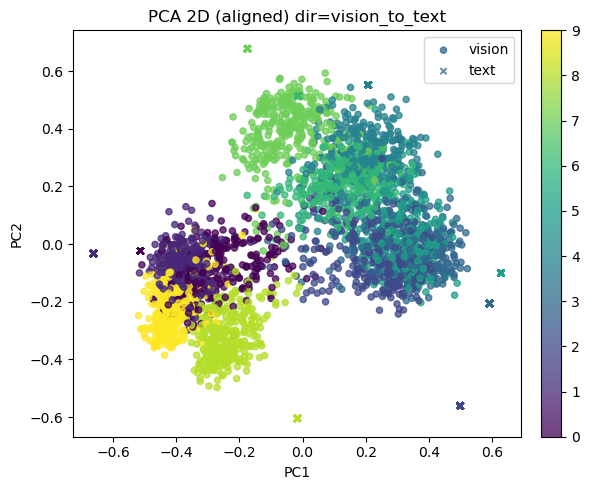

{'retrieval_orig': {1: 0.72119140625, 5: 0.99150390625, 10: 1.0},
 'retrieval_al': {1: 0.878125, 5: 0.98271484375, 10: 1.0},
 'gaps_orig': {'RMG': 0.8870930965337542,
  'L2M': 0.9383504062891006,
  'L2I': 1.2117053806781768,
  'cosineTP': 0.26562020778656004},
 'gaps_al': {'RMG': 0.6629355509226955,
  'L2M': 0.0832027131691575,
  'L2I': 0.980792686343193,
  'cosineTP': 0.5089237883687019},
 'clustering_orig': {'ARI': 0.3887693671620999,
  'NMI': np.float64(0.639405123169085),
  'Homogeneity': np.float64(0.6319788285917483),
  'V-measure': np.float64(0.639405123169085)},
 'clustering_al': {'ARI': 0.7667277412513904,
  'NMI': np.float64(0.8486351261423696),
  'Homogeneity': np.float64(0.8430124723617837),
  'V-measure': np.float64(0.8486351261423695)}}

In [21]:
def fit_orthogonal_procrustes_10k(train_loader, n_fit=10_000, translate=True, scale=False):
    """Fit Orthogonal Procrustes on 10k samples using `procrustes.orthogonal`."""
    X_fit, Y_fit = collect_embeddings(train_loader, max_samples=n_fit, device=device)
    res = orthogonal(X_fit, Y_fit, translate=translate, scale=scale)

    T = np.asarray(res.t, dtype=np.float32)
    fit_err = float(res.error) if not hasattr(res.error, "item") else float(res.error.item())

    mu_X = X_fit.mean(axis=0, keepdims=True)
    mu_Y = Y_fit.mean(axis=0, keepdims=True)
    eps = 1e-12
    s_X = np.linalg.norm(X_fit - mu_X, ord="fro") + eps
    s_Y = np.linalg.norm(Y_fit - mu_Y, ord="fro") + eps

    return {"T": T, "mu_X": mu_X, "mu_Y": mu_Y, "s_X": s_X, "s_Y": s_Y, "fit_error": fit_err}

def apply_mapping_torch(X: torch.Tensor, Y: torch.Tensor, mapping: dict, renorm: bool = True):
    """
    X, Y: torch tensors (B, D) on device
    mapping: dict with mu_X, s_X, mu_Y, s_Y, T (numpy or torch)
    Returns:
      X_al, Y_al: torch tensors (B, D)
    """
    eps = 1e-12

    # Ensure mapping params are torch tensors on the same device/dtype
    device = X.device
    dtype = X.dtype

    def to_torch(a):
        if torch.is_tensor(a):
            return a.to(device=device, dtype=dtype)
        return torch.as_tensor(a, device=device, dtype=dtype)

    mu_X = to_torch(mapping["mu_X"])
    s_X  = to_torch(mapping["s_X"])
    mu_Y = to_torch(mapping["mu_Y"])
    s_Y  = to_torch(mapping["s_Y"])
    T    = to_torch(mapping["T"])

    Xp = (X - mu_X) / (s_X + eps)
    Yp = (Y - mu_Y) / (s_Y + eps)

    X_al = Xp @ T
    Y_al = Yp

    if renorm:
        X_al = X_al / (X_al.norm(dim=1, keepdim=True) + eps)
        Y_al = Y_al / (Y_al.norm(dim=1, keepdim=True) + eps)

    return X_al, Y_al

def eval_orthogonal_procrustes(
        test_loader,
        dataset,
        label_to_embedding,
        mapping_model,
        direction="vision_to_text",
        do_clustering=True,
        n_clusters=10,
        max_cluster_samples=5000,
        plot_pca=True,
):
    gaps = ["RMG", "L2M", "L2I", "cosineTP"]
    r_orig = {1: [], 5: [], 10: []}
    r_al = {1: [], 5: [], 10: []}
    gaps_orig_batches = {g: [] for g in gaps}
    gaps_al_batches = {g: [] for g in gaps}

    # buffers per clustering    
    X_buf, Y_buf, L_buf = [], [], []
    Xa_buf, Ya_buf = [], []

    def _to_scalar(v):
        if isinstance(v, dict):
            v = v.get("text_vision", next(iter(v.values())))
        if torch.is_tensor(v):
            v = v.item()
        return float(v)

    seen = 0

    with torch.no_grad():
        for text, vision, labels in tqdm(test_loader, desc="Eval orthogonal pre/post"):
            X = F.normalize(text.to(device), dim=-1)
            Y = F.normalize(vision.to(device), dim=-1)
            labels = labels.to(device)

            inputs = (X, Y, labels) if direction == "text_to_vision" else (Y, X, labels)
            r_orig[1].append(_to_scalar(compute_retrieval(dataset, inputs, top_k=1, labels_to_emb=label_to_embedding)))
            r_orig[5].append(_to_scalar(compute_retrieval(dataset, inputs, top_k=5, labels_to_emb=label_to_embedding)))
            r_orig[10].append(_to_scalar(compute_retrieval(dataset, inputs, top_k=10, labels_to_emb=label_to_embedding)))

            X_al, Y_al = apply_mapping_torch(X, Y, mapping_model, renorm=True)
            inputs_al = (X_al, Y_al, labels) if direction == "text_to_vision" else (Y_al, X_al, labels)
            r_al[1].append(_to_scalar(compute_retrieval(dataset, inputs_al, top_k=1, labels_to_emb=label_to_embedding)))
            r_al[5].append(_to_scalar(compute_retrieval(dataset, inputs_al, top_k=5, labels_to_emb=label_to_embedding)))
            r_al[10].append(_to_scalar(compute_retrieval(dataset, inputs_al, top_k=10, labels_to_emb=label_to_embedding)))

            for gname in gaps:
                go = compute_gap(gname, X, Y, iterations=None)
                ga = compute_gap(gname, X_al, Y_al, iterations=None)
                gaps_orig_batches[gname].append(_to_scalar(go))
                gaps_al_batches[gname].append(_to_scalar(ga))

            # --- CLUSTERING BUFFERS ---
            if do_clustering and seen < max_cluster_samples:
                b = min(X.shape[0], max_cluster_samples - seen)
                X_buf.append(X[:b].detach().cpu())
                Y_buf.append(Y[:b].detach().cpu())
                Xa_buf.append(X_al[:b].detach().cpu())
                Ya_buf.append(Y_al[:b].detach().cpu())
                L_buf.append(labels[:b].detach().cpu())
                seen += b

    gaps_orig = {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()}
    gaps_al = {g: float(np.mean(v)) for g, v in gaps_al_batches.items()}

    print(f"\n=== TEST RESULTS ORTHOGONAL (direction: {direction}) ===")
    print(f"Orthogonal fit_error on 10k: {mapping_model['fit_error']:.6f}")
    print(f"Retrieval@1  orig: {np.mean(r_orig[1]):.4f} | aligned: {np.mean(r_al[1]):.4f}")
    print(f"Retrieval@5  orig: {np.mean(r_orig[5]):.4f} | aligned: {np.mean(r_al[5]):.4f}")
    print(f"Retrieval@10 orig: {np.mean(r_orig[10]):.4f} | aligned: {np.mean(r_al[10]):.4f}")
    print("Gaps original:", gaps_orig)
    print("Gaps aligned :", gaps_al)

    # --- CLUSTERING E VISUALIZZAZIONE ---
    if do_clustering and len(X_buf) > 0:
        X_all  = torch.cat(X_buf, dim=0)
        Y_all  = torch.cat(Y_buf, dim=0)
        Xa_all = torch.cat(Xa_buf, dim=0)
        Ya_all = torch.cat(Ya_buf, dim=0)
        L_all  = torch.cat(L_buf, dim=0)

        print(f"\n[Clustering] using N={X_all.shape[0]} samples (then 2N points for KMeans).")

        m_orig = _clustering_metrics_two_modalities(X_all, Y_all, L_all, n_clusters=n_clusters, random_state=0)
        m_al   = _clustering_metrics_two_modalities(Xa_all, Ya_all, L_all, n_clusters=n_clusters, random_state=0)

        print(f"[Clustering KMeans k={n_clusters}]")
        print(f"  ORIG   ARI={m_orig['ARI']:.4f} | NMI={m_orig['NMI']:.4f} | Hom={m_orig['Homogeneity']:.4f} | V={m_orig['V-measure']:.4f}")
        print(f"  ALIGNED ARI={m_al['ARI']:.4f} | NMI={m_al['NMI']:.4f} | Hom={m_al['Homogeneity']:.4f} | V={m_al['V-measure']:.4f}")

        if plot_pca:
            _plot_pca_2d(m_orig["emb_2N"], m_orig["true_labels_2N"], title=f"PCA 2D (orig) dir={direction}")
            _plot_pca_2d(m_al["emb_2N"],   m_al["true_labels_2N"], title=f"PCA 2D (aligned) dir={direction}")

        return {
            "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
            "retrieval_al":   {k: float(np.mean(v)) for k, v in r_al.items()},
            "gaps_orig": gaps_orig,
            "gaps_al": gaps_al,
            "clustering_orig": {k: m_orig[k] for k in ["ARI","NMI","Homogeneity","V-measure"]},
            "clustering_al":   {k: m_al[k] for k in ["ARI","NMI","Homogeneity","V-measure"]},
        }

    return {
        "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_al":   {k: float(np.mean(v)) for k, v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_al": gaps_al,
    }


mapping_orth_10k = fit_orthogonal_procrustes_10k(train_loader, n_fit=10_000, translate=True, scale=False)
out_orth = eval_orthogonal_procrustes(
    test_loader, dataset, label_to_embedding, mapping_orth_10k,
    direction="vision_to_text",
    do_clustering=True,
    n_clusters=10,
    max_cluster_samples=5000,
    plot_pca=True
)
out_orth

### Subspace alignment

In [6]:
from subspace_alignment.subspace_alignment import fit_subspace_alignment, apply_subspace_alignment, analyze_subspace_dimensions, eval_subspace_alignment_cifar10
dataset_name = dataset

In [7]:
train_loader, test_loader = make_loaders(batch_size=256, seed=0, num_workers=0)

[Loaded] 50000 samples from /mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_train_ViT-B-32_laion2b_s34b_b79k | text_emb shape=(50000, 512)
[Loaded] 10000 samples from /mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_test_ViT-B-32_laion2b_s34b_b79k | text_emb shape=(10000, 512)


In [8]:
#Let's get it from the training set, since it contains more samples per class and thus the average embedding will be more stable
label_to_embedding = {}
with torch.no_grad():
    for text_b, vis_b, labels in tqdm(train_loader, desc="Building label_to_embedding dict"):
        for text_emb, vis_emb, label in zip(text_b, vis_b, labels):
            label = label.item()
            if label not in label_to_embedding:
                label_to_embedding[label] = {"text": []}
                label_to_embedding[label] = text_emb

Building label_to_embedding dict: 100%|██████████| 196/196 [00:00<00:00, 279.68it/s]


Collected 50000 samples of dimension 512


Eval subspace alignment: 100%|██████████| 40/40 [00:00<00:00, 66.02it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 32
Retrieval@1  orig: 0.7212 | aligned: 0.7563
Retrieval@5  orig: 0.9915 | aligned: 0.9502
Retrieval@10 orig: 1.0000 | aligned: 1.0000
Gaps original: {'RMG': 0.8870930965337542, 'L2M': 0.9383504062891006, 'L2I': 1.2117053806781768, 'cosineTP': 0.26562020778656004}
Gaps aligned : {'RMG': 0.6468221367658431, 'L2M': 0.09084463734179735, 'L2I': 0.35602530688047407, 'cosineTP': 0.9323748528957367}

[Clustering] using N=5000 samples (then 2N points for KMeans).
[Clustering KMeans k=10]
  ORIG   ARI=0.3888 | NMI=0.6394 | Hom=0.6320 | V=0.6394
  ALIGNED ARI=0.5025 | NMI=0.7313 | Hom=0.7057 | V=0.7313


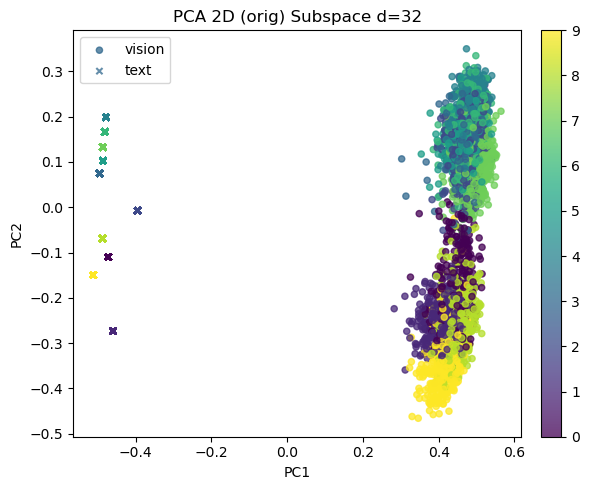

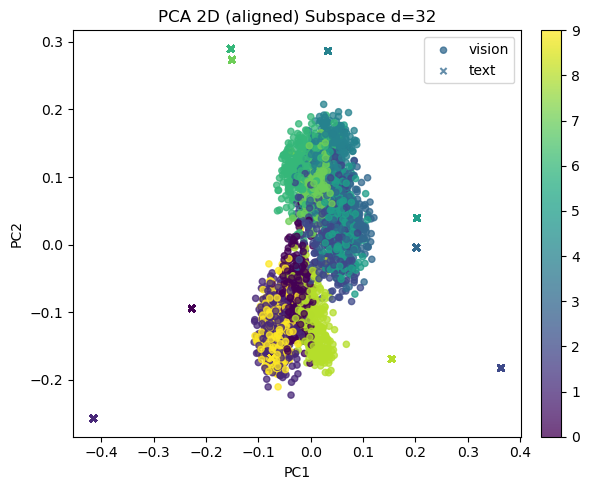

Collected 50000 samples of dimension 512


Eval subspace alignment: 100%|██████████| 40/40 [00:00<00:00, 100.94it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 64
Retrieval@1  orig: 0.7212 | aligned: 0.7553
Retrieval@5  orig: 0.9915 | aligned: 0.9521
Retrieval@10 orig: 1.0000 | aligned: 1.0000
Gaps original: {'RMG': 0.8870930965337542, 'L2M': 0.9383504062891006, 'L2I': 1.2117053806781768, 'cosineTP': 0.26562020778656004}
Gaps aligned : {'RMG': 0.6657247450754077, 'L2M': 0.078489457257092, 'L2I': 0.3906218700110912, 'cosineTP': 0.9199551478028297}

[Clustering] using N=5000 samples (then 2N points for KMeans).
[Clustering KMeans k=10]
  ORIG   ARI=0.3888 | NMI=0.6394 | Hom=0.6320 | V=0.6394
  ALIGNED ARI=0.5793 | NMI=0.7819 | Hom=0.7568 | V=0.7819


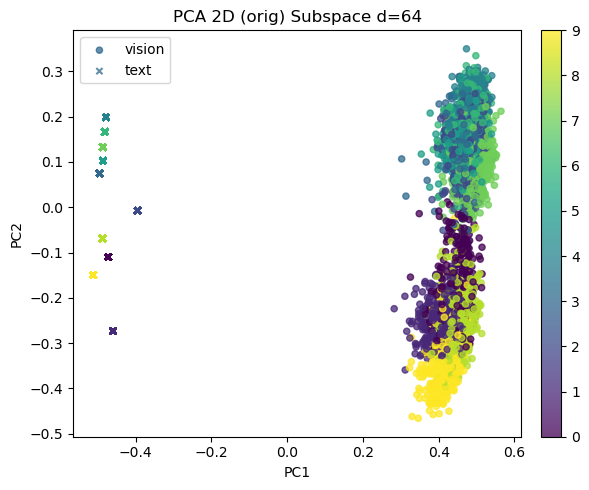

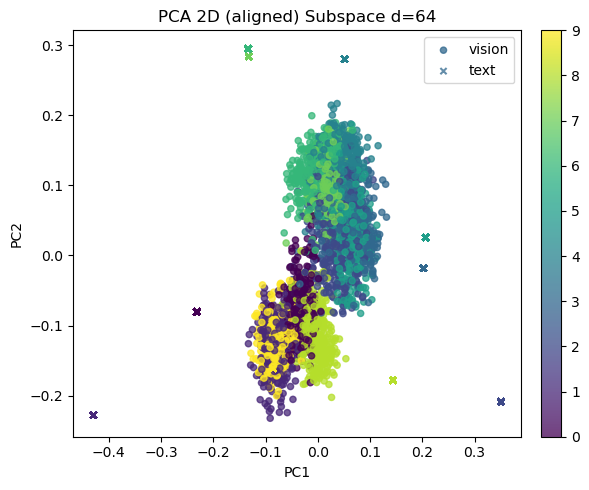

Collected 50000 samples of dimension 512


Eval subspace alignment: 100%|██████████| 40/40 [00:00<00:00, 102.08it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 128
Retrieval@1  orig: 0.7212 | aligned: 0.7539
Retrieval@5  orig: 0.9915 | aligned: 0.9536
Retrieval@10 orig: 1.0000 | aligned: 1.0000
Gaps original: {'RMG': 0.8870930965337542, 'L2M': 0.9383504062891006, 'L2I': 1.2117053806781768, 'cosineTP': 0.26562020778656004}
Gaps aligned : {'RMG': 0.6950696968114192, 'L2M': 0.05421762354671955, 'L2I': 0.4567140392959118, 'cosineTP': 0.8928722038865089}

[Clustering] using N=5000 samples (then 2N points for KMeans).
[Clustering KMeans k=10]
  ORIG   ARI=0.3888 | NMI=0.6394 | Hom=0.6320 | V=0.6394
  ALIGNED ARI=0.5840 | NMI=0.7655 | Hom=0.7495 | V=0.7655


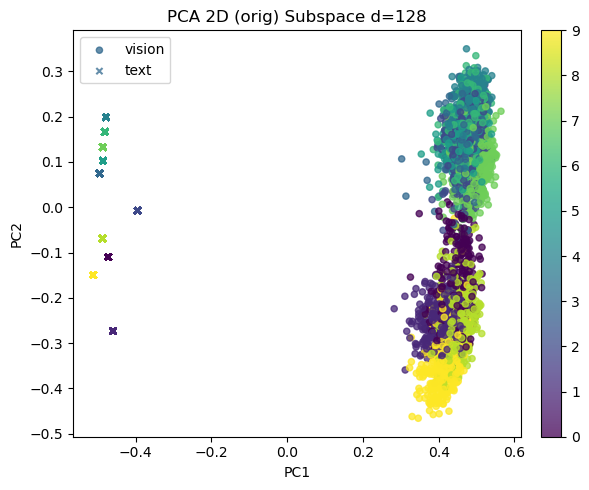

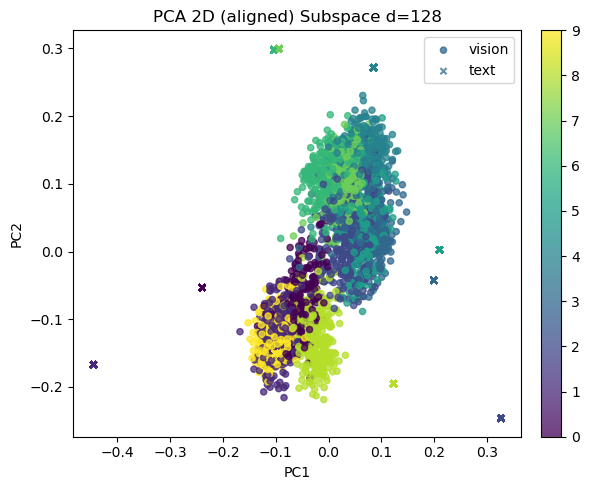

Collected 50000 samples of dimension 512


Eval subspace alignment: 100%|██████████| 40/40 [00:00<00:00, 100.91it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 256
Retrieval@1  orig: 0.7212 | aligned: 0.7557
Retrieval@5  orig: 0.9915 | aligned: 0.9525
Retrieval@10 orig: 1.0000 | aligned: 1.0000
Gaps original: {'RMG': 0.8870930965337542, 'L2M': 0.9383504062891006, 'L2I': 1.2117053806781768, 'cosineTP': 0.26562020778656004}
Gaps aligned : {'RMG': 0.7331034703386582, 'L2M': 0.04185242298990488, 'L2I': 0.5738988220691681, 'cosineTP': 0.8328954368829727}

[Clustering] using N=5000 samples (then 2N points for KMeans).
[Clustering KMeans k=10]
  ORIG   ARI=0.3888 | NMI=0.6394 | Hom=0.6320 | V=0.6394
  ALIGNED ARI=0.5987 | NMI=0.7660 | Hom=0.7502 | V=0.7660


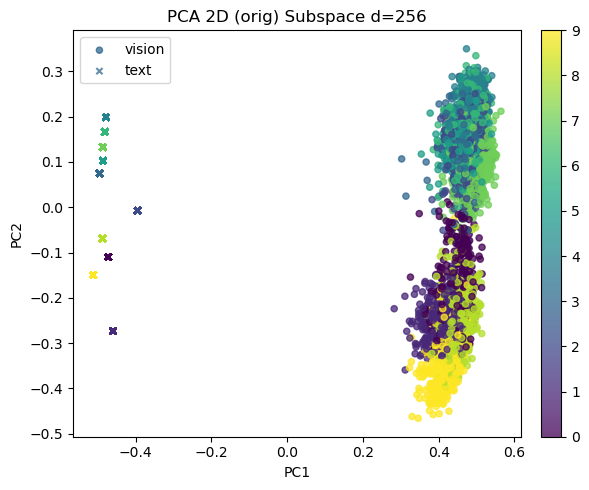

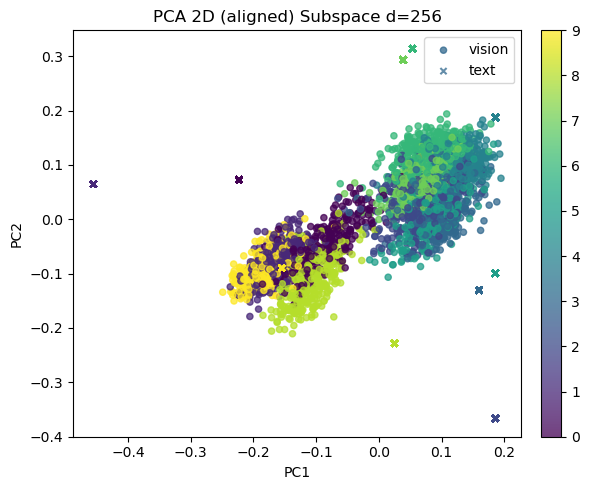

Collected 50000 samples of dimension 512


Eval subspace alignment: 100%|██████████| 40/40 [00:00<00:00, 98.56it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 384
Retrieval@1  orig: 0.7212 | aligned: 0.7555
Retrieval@5  orig: 0.9915 | aligned: 0.9536
Retrieval@10 orig: 1.0000 | aligned: 1.0000
Gaps original: {'RMG': 0.8870930965337542, 'L2M': 0.9383504062891006, 'L2I': 1.2117053806781768, 'cosineTP': 0.26562020778656004}
Gaps aligned : {'RMG': 0.7506059178564035, 'L2M': 0.07963847909122705, 'L2I': 0.6506652191281319, 'cosineTP': 0.7862616509199143}

[Clustering] using N=5000 samples (then 2N points for KMeans).
[Clustering KMeans k=10]
  ORIG   ARI=0.3888 | NMI=0.6394 | Hom=0.6320 | V=0.6394
  ALIGNED ARI=0.5453 | NMI=0.7526 | Hom=0.7307 | V=0.7526


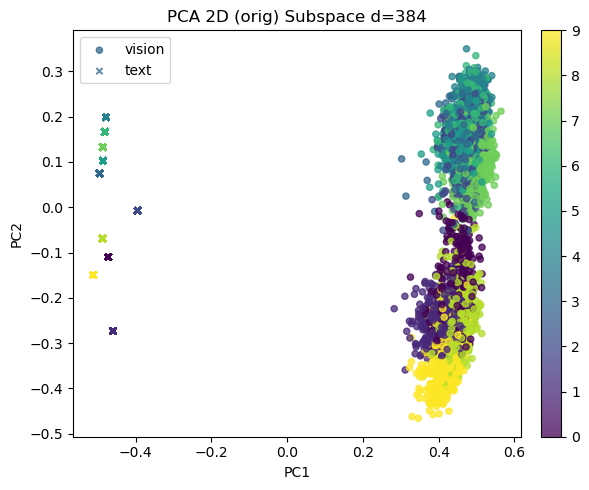

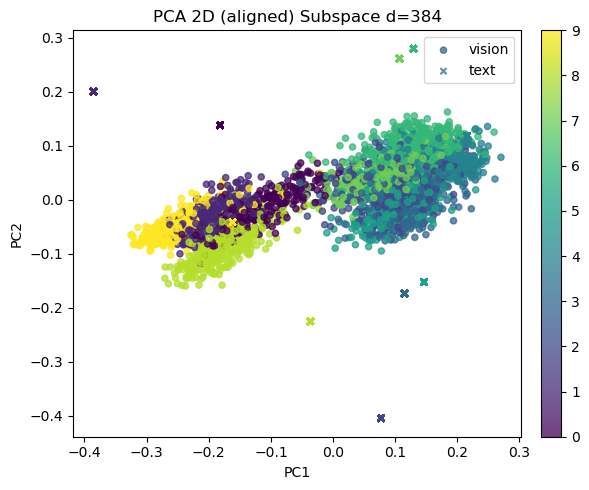

Collected 50000 samples of dimension 512


Eval subspace alignment: 100%|██████████| 40/40 [00:00<00:00, 98.80it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 512
Retrieval@1  orig: 0.7212 | aligned: 0.7550
Retrieval@5  orig: 0.9915 | aligned: 0.9525
Retrieval@10 orig: 1.0000 | aligned: 1.0000
Gaps original: {'RMG': 0.8870930965337542, 'L2M': 0.9383504062891006, 'L2I': 1.2117053806781768, 'cosineTP': 0.26562020778656004}
Gaps aligned : {'RMG': 0.7613876416854267, 'L2M': 0.11524201985448598, 'L2I': 0.7055173605680466, 'cosineTP': 0.7491925388574601}

[Clustering] using N=5000 samples (then 2N points for KMeans).
[Clustering KMeans k=10]
  ORIG   ARI=0.3888 | NMI=0.6394 | Hom=0.6320 | V=0.6394
  ALIGNED ARI=0.6730 | NMI=0.8064 | Hom=0.7958 | V=0.8064


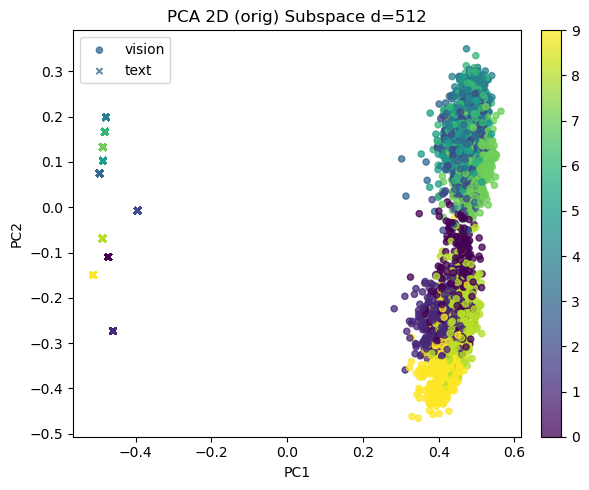

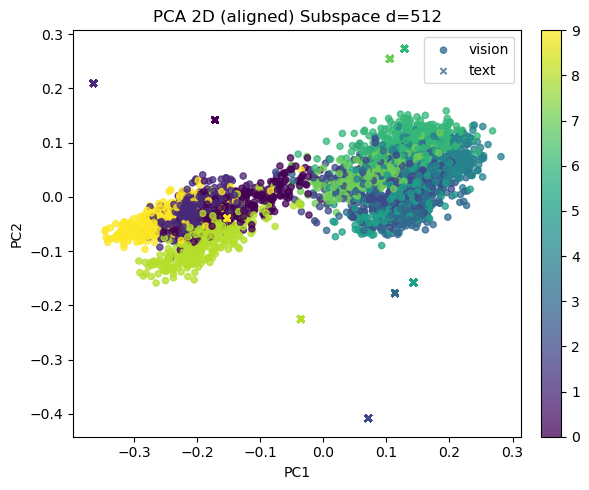

In [9]:
for d in [32, 64, 128, 256, 384, 512]:
    sub_model = fit_subspace_alignment(train_loader, d_sub=d)
    _ = eval_subspace_alignment_cifar10(test_loader, sub_model, labels_to_emb=label_to_embedding)

## MSCOCO